In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import math

I forbindelse af vores analyse var vi interesseret i at tjekke om 'Unik Kode (ui)' er unik, for at sikre os identifiction af et stykke tøj for at kunne følge det gennem tiden. Det viser sig at Unik kode ikke er unik. Dette vises nedenfor 

In [3]:
#All data together

folder = Path(
    "C:/Users/tobia/OneDrive/Skrivebord/UNI/4. semester/Dataprojekt/2023 AAR vaskeri data"
)
files = list(folder.glob("PLC*.xlsx"))            # matches PLC, Product....xlsx etc.

dfs = []
monthly_data = {}

for f in files:
    df = pd.read_excel(f, header=2)                         # optionally: sheet_name="Sheet1"
    df["source_file"] = f.name                    # helpful traceability
    dfs.append(df)

    #dataframe for each individual month
    month_name = f.stem
    monthly_data[month_name] = df

all_data = pd.concat(dfs, ignore_index=True)


In [7]:
n_unique_prod_year = (
    all_data
    .dropna(subset=["Unik Kode (ui)"])
    .groupby("Unik Kode (ui)")["Produkt - Produkt"] #group by ui and look at product for each group
    .nunique() #counting how many products each ui maps to
)
bad_ui_year = n_unique_prod_year[n_unique_prod_year > 1].index #filter for only conflicting ui's

conflicts_year = (
            all_data[all_data["Unik Kode (ui)"].isin(bad_ui_year)] #selecting rows which ui's are non-unique
            .loc[:, ["Unik Kode (ui)", "Produkt - Produkt", "source_file"]] # selecting only the stated rows
            .drop_duplicates() #dropping duplicates of bad ui's (same prod, same ui, same file)
            .sort_values(["Unik Kode (ui)", "Produkt - Produkt"]) #sorting for readability
        )

print("Number of conflicting UI codes in full dataset:", len(bad_ui_year))
print(f"Number of total entries in the data set: {len(all_data)}")
conflicts_year.head(10)


Number of conflicting UI codes in full dataset: 439
Number of total entries in the data set: 248711


,Unik Kode (ui),Produkt - Produkt,source_file
83199,00D007440139,09182 Overall Kblå Hygiejne,"PLC, Product detaljeret, Aarhus, Jan. 2023.xlsx"
100711,00D007440139,23361 Overall Food Kblå,"PLC, Product detaljeret, Aarhus, Jan. 2023.xlsx"
26700,00D0075C79CB,06325 Kokkebuss. Brod. Grå P/B,"PLC, Product detaljeret, Aarhus, Aug. 2023.xlsx"
228354,00D0075C79CB,06325 Kokkebuss. Brod. Grå P/B,"PLC, Product detaljeret, Aarhus, Okt. 2023.xlsx"
39935,00D0075C79CB,30206 Jakke Løvbjerg sort,"PLC, Product detaljeret, Aarhus, Aug. 2023.xlsx"
55818,00D0085C7770,01806 Jakke Termo Marineblå,"PLC, Product detaljeret, Aarhus, Feb. 2023.xlsx"
79324,00D0085C7770,23897 Termojakke u/lom mblå,"PLC, Product detaljeret, Aarhus, Feb. 2023.xlsx"
89563,00D0085D8F1F,09182 Overall Kblå Hygiejne,"PLC, Product detaljeret, Aarhus, Jan. 2023.xlsx"
100712,00D0085D8F1F,23361 Overall Food Kblå,"PLC, Product detaljeret, Aarhus, Jan. 2023.xlsx"
75071,00D00960C27E,10129 Overall FlmQ so/grå brystlom,"PLC, Product detaljeret, Aarhus, Feb. 2023.xlsx"


Af dette kode ses det at der er 439 tilfælde af Unikke koder tildelt til forskellige stykker tøj i vores dataset med 248711 observationer. Dermed udgør de ikke in stor del af datasættet. Vi undersøgte dernæst om problemet forekom i hvert datasæt, da det kan ses på tabellen ovenfor at flere måneder er repræsenteret.

In [8]:
#Unique ui check
conflicts_by_month = {}

for month, df in monthly_data.items():
    #counting distinct products per ui code
    n_unique_prod = (
        df.dropna(subset=["Unik Kode (ui)"]) #ignore rows with no ui
        .groupby("Unik Kode (ui)")["Produkt - Produkt"] #group by ui and look at product for each group
        .nunique() #counting how many products each ui maps to
    )
    
    bad_ui = n_unique_prod[n_unique_prod > 1].index #indexes of uis with more than one product attached

    if len(bad_ui) > 0: #ui not unique
        conflicts = (
            df[df["Unik Kode (ui)"].isin(bad_ui)] #selecting rows which ui's are non-unique
            .loc[:, ["Unik Kode (ui)", "Produkt - Produkt", "source_file"]] # selecting only the stated rows
            .drop_duplicates() #dropping duplicates of bad ui's (same prod, same ui, same file)
            .sort_values(["Unik Kode (ui)", "Produkt - Produkt"]) #sorting for readability
        )
        conflicts_by_month[month] = conflicts #store a df of each months bad ui's
        print(f"{month}: ui codes map to multiple products")

    else: #all ui's unique
        print(f"{month}: All ui codes map a single product.")

PLC, Product detaljeret, Aarhus, Apr. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Aug. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Dec. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Feb. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Jan. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Jul. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Jun. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Maj, 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Mar. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Nov. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Okt. 2023: ui codes map to multiple products
PLC, Product detaljeret, Aarhus, Sep. 2023: ui codes map to multiple products


Vi kan nu bekræfte at dette problem findes i alle vores datasæt og at flere forskellige typer tøj har tilfælde med samme unikke kode.

For at få et overblik over subsættet filtrede vi dem fra, for dybere analyse. Vi undersøgte deres kassationsårsager, dage i cirkulation og hvor mange stykker tøj, der er tilknyttet samme kode.

In [9]:
# 2. Filtrer all_data for kun at beholde de koder, der har konflikter
conflicts_raw = all_data[all_data["Unik Kode (ui)"].isin(bad_ui_year)]

# 3. Aggreger til én række pr. kode med lister
# Vi bruger .unique() på produktnavne for at se de forskellige navne, 
# men beholder hele historikken for dage og årsager.
conflicts_grouped = (
    conflicts_raw
    .groupby("Unik Kode (ui)")
    .agg({
        "Produkt - Produkt": lambda x: list(x.unique()),
        "Dage i cirkulation": list,
        "Kassationsårsag (ui)": list
    })
    .reset_index()
)

# Omdøb kolonner for klarhed
conflicts_grouped.columns = ["Unik Kode (ui)", "Produktnavne", "Dage_Historik", "Aarsager_Historik"]

conflicts_grouped.head(10)

,Unik Kode (ui),Produktnavne,Dage_Historik,Aarsager_Historik
0,00D007440139,"[09182 Overall Kblå Hygiejne, 23361 Overall Fo...","[1626, 0]","[Udgået Model, Udgået Model]"
1,00D0075C79CB,"[06325 Kokkebuss. Brod. Grå P/B, 30206 Jakke L...","[1361, 0, 0]","[BTS fejl uden restværdi, BTS fejl uden restvæ..."
2,00D0085C7770,"[01806 Jakke Termo Marineblå, 23897 Termojakke...","[3997, 0]","[Misligholdt med restværdi, BTS fejl uden rest..."
3,00D0085D8F1F,"[09182 Overall Kblå Hygiejne, 23361 Overall Fo...","[743, 0]","[Udgået Model, Udgået Model]"
4,00D00960C27E,"[10129 Overall FlmQ so/grå brystlom, 25995 Ove...","[98, 0]","[Udgået Model, Alm.slid uden restværdi]"
5,00D009AFC9AD,"[22571 Dunjakke Outdoor C uni sort, 13694 Jakk...","[445, 60]","[Udgået Model, Udgået Model]"
6,00D009E24B0F,"[14147 Jakke 2 indvlom hv high risk, 14141 Jak...","[0, 38]","[Videresalg til kunder, Misligholdt med restvæ..."
7,00D00A2B05E2,"[25996 Buks FlamePro NY sort/grå, 13210 Benklæ...","[27, 1756]","[Misligholdt med restværdi, Udgået Model]"
8,00D00A57D4D1,"[09195 Overall M.Knæl Grå/Sort Bom, 02813 Over...","[0, 0]","[Udgået Model, Udgået Model]"
9,00D00A5CFA2D,"[09182 Overall Kblå Hygiejne, 23361 Overall Fo...","[399, 262]","[Udgået Model, Udgået Model]"


I denne tabel ses et slice af dataframe bestående af subsættet af dårlige ui's. Kolonnerne "Produktnavne", "Dage_Historik" og "Aarsager_Historik" består af lister der repræsenterer hvert stykke tøjs produktinformation, antal dage i cirkulation og årsagen for kassation for hvert stykke tøj tilhørende samme unikke kode.

Allerede fra dette slice af subsættet med dårlige koder ses det på række 1 at der er forekomster af unikke koder tildelt >2 stykker tøj. Det ses også at der er tilfælde af tøj der er kasseret med årsag= "Udgået Model" uden vi har information om antal dage i cirkulation, da Dage_Historik = 0 (Eks. Række 0). Dette illustrerer at selv ved korrekt identifikation af et stykke tøj på anden vis end med "Unik Kode (ui)", så er der endnu en problematik der skal håndteres / findes svar på, men dette vil IKKE gøres her. 

Fra dette slice er det ikke tydeligt hvorvidt den samme model af tøj optræder flere gange med samme unikke kode, eks Produktnavne = [25996 Buks, 25995 Buks]. Det skal dog bemærkes at selv hvis dette tilfælde optræder, så der ingen garanti for at det er det samme stykke tøj, der er kasseret af flere omgange, men vi mener det er en plausibel antagelse.

In [29]:
conflicts_same_clothing = (
    conflicts_raw
    .groupby("Unik Kode (ui)")
    .agg(
        Produktnavne=("Produkt - Produkt", lambda x: x.astype(str).str.strip().tolist()),
        Dage_Historik=("Dage i cirkulation", list),
        Aarsager_Historik=("Kassationsårsag (ui)", list),
    )
    .reset_index()
)

# True hvis der findes dubletter i listen (samme navn flere gange)
conflicts_same_clothing["har_dublet_produktnavn"] = conflicts_same_clothing["Produktnavne"].apply(
    lambda lst: len(lst) != len(set(lst)) #fungerer da set() fjerne dubletter
)

# Kun de interessante tilfælde
samme_navn_flere_gange = conflicts_same_clothing[conflicts_same_clothing["har_dublet_produktnavn"]].copy()
row = samme_navn_flere_gange.iloc[12]

for col in samme_navn_flere_gange.columns:
    print(f"{col}:")
    
    value = row[col]
    
    if isinstance(value, list):
        for v in value:
            print("  -", v)
    else:
        print(" ", value)
    
    print()
print(f"Antal tilfælde med samme Produkt optrædende flere gange under samme UI: {len(samme_navn_flere_gange)}")

Unik Kode (ui):
  30155C97D461A7C001FC38E8

Produktnavne:
  - 09654 Benkl Prostretch Kblå P/B
  - 09654 Benkl Prostretch Kblå P/B
  - 08600 Benkl u knæ mblå Icon

Dage_Historik:
  - 33
  - 59
  - 0

Aarsager_Historik:
  - Misligholdt med restværdi
  - Udgået Model
  - Udgået Model

har_dublet_produktnavn:
  True

Antal tilfælde med samme Produkt optrædende flere gange under samme UI: 15


Så under vores antagelse at samme produktnavn = samme stykke tøj, så er der 15 tilfælde hvor et stykke tøj er kasseret af flere omgange. Yderligere kommentarer vil vi ikke give, da vi ikke har garanti for at Dage_historik bliver udskrevet i kronologisk rækkefølge.

Dernæst kiggede vi på levetiden for de 439 koder med produktkonflikter. Vi lavede et scatterplot for hver forekomst i datasættet for at prøve at tolke på årsagen til disse produktkonflikter.

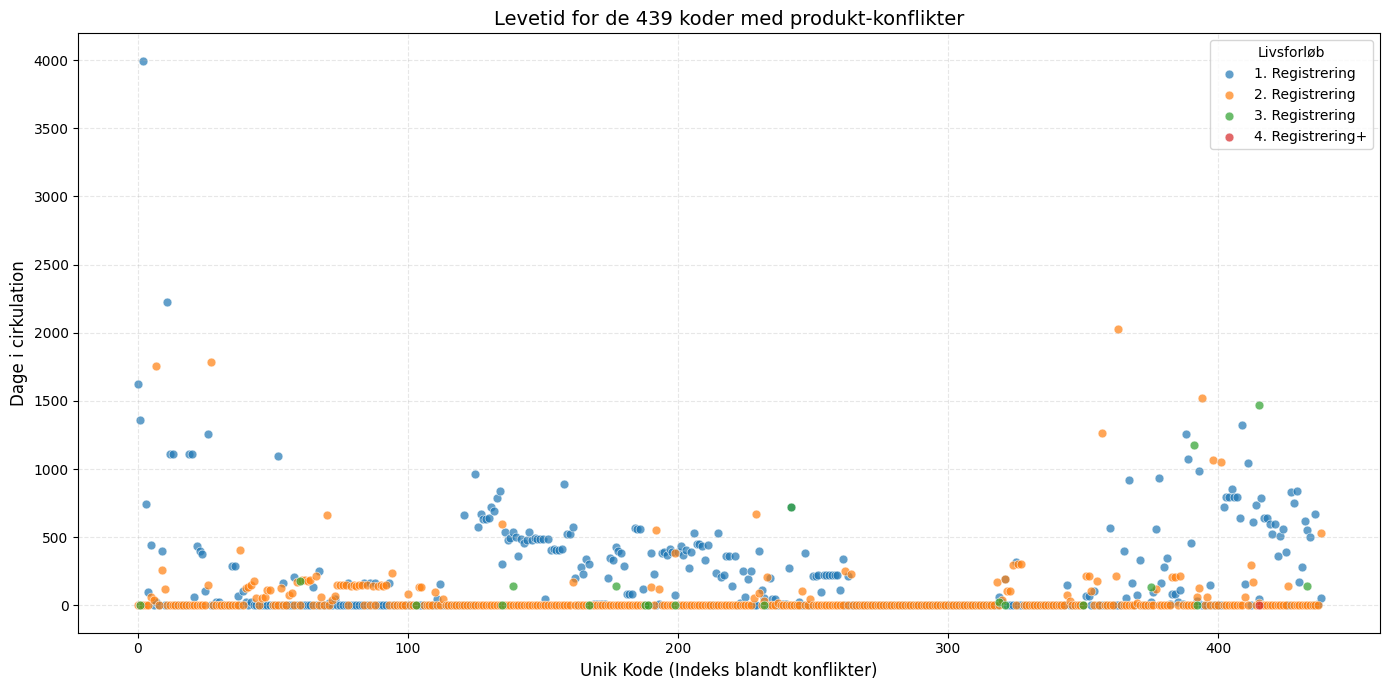

In [30]:
plot_data = []
for i, row in conflicts_grouped.iterrows():
    for index, dage in enumerate(row['Dage_Historik']):
        plot_data.append({
            'ID_Index': i, 
            'Dage': dage, 
            'Liv_Nummer': index + 1
        })

plot_df = pd.DataFrame(plot_data)

# 5. Generer scatterplot
plt.figure(figsize=(14, 7))
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}
labels = {1: '1. Registrering', 2: '2. Registrering', 3: '3. Registrering', 4: '4. Registrering+'}

for life in sorted(plot_df['Liv_Nummer'].unique()):
    subset = plot_df[plot_df['Liv_Nummer'] == life]
    plt.scatter(subset['ID_Index'], subset['Dage'], 
                color=colors.get(life, 'black'), 
                label=labels.get(life), 
                alpha=0.7, s=40, edgecolors='w', linewidth=0.5)

plt.title(f'Levetid for de {len(conflicts_grouped)} koder med produkt-konflikter', fontsize=14)
plt.xlabel('Unik Kode (Indeks blandt konflikter)', fontsize=12)
plt.ylabel('Dage i cirkulation', fontsize=12)
plt.legend(title="Livsforløb")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

Det ses at langt størstedelen af >2 registreringerne forkommer med "Dage i cirkulation"= 0. Dette kan plausibelt forklares ved tøj der er lagt på lager og kasseres efterfølgende, hvor det i kassationen registreres igen. Det dog sandsynligt at der er en anden forklaring, men uden  kontakt til virksomheden kan vi ikke lave andet en logiske antagelser med den begrænsede viden vi har om deres virksomhedsdrift. 

Der er tilfælde hvor anden-,tredje- registreringen har dage i cirkulation > 0, men dette kan plausibelt forklares af forskellige typer tøj med samme unikke kode der er i cirkulation, hvor de vaskes og kasseres på forskellige tidspunkter.

For at illustrere den enorme mængde af forkomster med "Dage i cirkulation" = 0, lavede vi dette plot, hvor vi ikke bruger datapunkter hvor 2.registrering > 0.

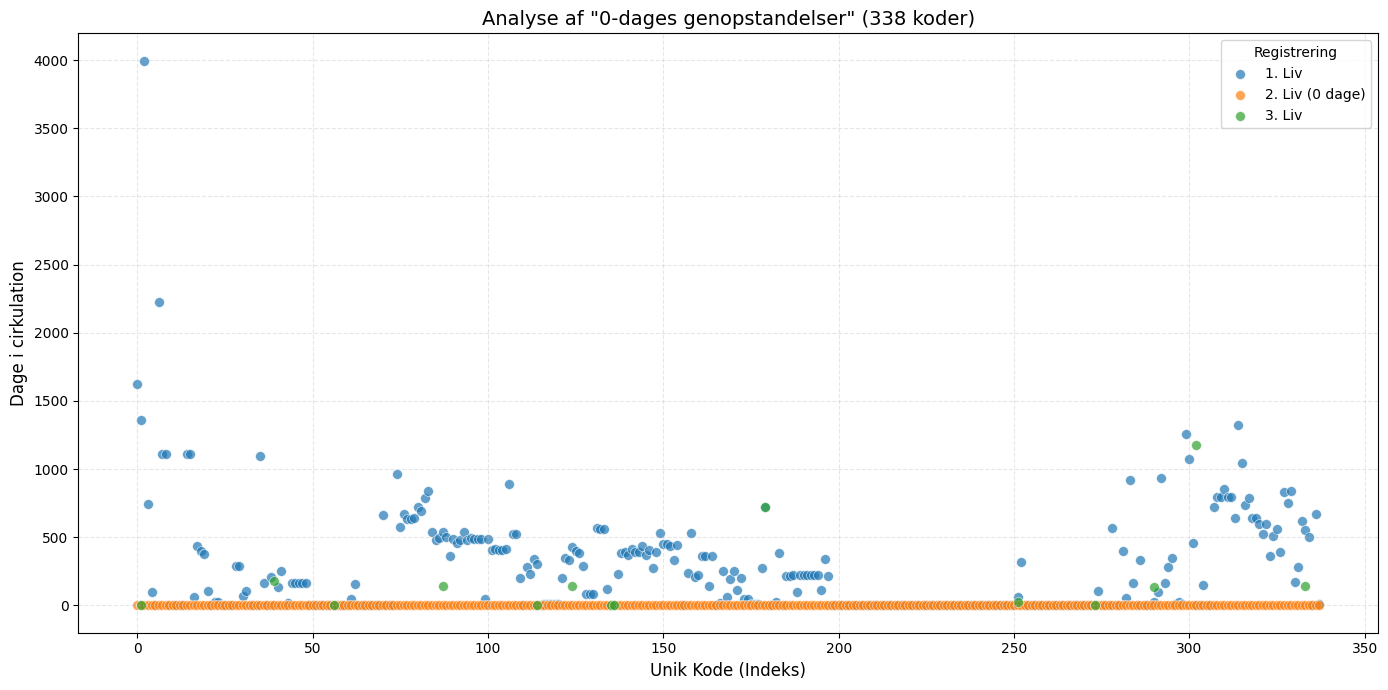

Antal koder hvor 2. liv er præcis 0 dage: 338


In [36]:
conflicts_raw = all_data[all_data["Unik Kode (ui)"].isin(bad_ui_year)].copy()
# Vi sikrer os at de er sorteret efter måned (Month_Num skal være oprettet tidligere)
conflicts_raw = conflicts_raw.sort_values(['Unik Kode (ui)', 'source_file'])

conflicts_grouped = (
    conflicts_raw
    .groupby("Unik Kode (ui)")
    .agg({
        "Produkt - Produkt": lambda x: list(x.unique()),
        "Dage i cirkulation": list,
        "Kassationsårsag (ui)": list
    })
    .reset_index()
)
# 1. Brug din eksisterende 'conflicts_grouped' tabel
# Vi filtrerer for koder, der har mindst to registreringer, hvor den anden er 0
mask_second_life_zero = (
    conflicts_grouped['Dage i cirkulation'].apply(lambda x: len(x) > 1 and x[1] == 0)
)

conflicts_zero_second = conflicts_grouped[mask_second_life_zero].copy()

# 2. Forbered data til plot
plot_data_zero = []
for i, row in conflicts_zero_second.reset_index().iterrows():
    for index, dage in enumerate(row['Dage i cirkulation']):
        plot_data_zero.append({
            'ID_Index': i, 
            'Dage': dage, 
            'Liv_Nummer': index + 1
        })

plot_df_zero = pd.DataFrame(plot_data_zero)

# 3. Generer scatterplot
plt.figure(figsize=(14, 7))
colors = {1: '#1f77b4', 2: '#ff7f0e', 3: '#2ca02c', 4: '#d62728'}
labels = {1: '1. Liv', 2: '2. Liv (0 dage)', 3: '3. Liv', 4: '4. Liv+'}

for life in sorted(plot_df_zero['Liv_Nummer'].unique()):
    subset = plot_df_zero[plot_df_zero['Liv_Nummer'] == life]
    plt.scatter(subset['ID_Index'], subset['Dage'], 
                color=colors.get(life, 'black'), 
                label=labels.get(life), 
                alpha=0.7, s=50, edgecolors='w', linewidth=0.5)

plt.title(f'Analyse af "0-dages genopstandelser" ({len(conflicts_zero_second)} koder)', fontsize=14)
plt.xlabel('Unik Kode (Indeks)', fontsize=12)
plt.ylabel('Dage i cirkulation', fontsize=12)
plt.legend(title="Registrering")
plt.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Antal koder hvor 2. liv er præcis 0 dage: {len(conflicts_zero_second)}")

Det ses altså at 2.liv = 0 dage repræsenterer en væsentlig del af dette subsæt af data.

Problemet ved at beholde dette data i vores fremtidige analyse er introducering af bias, så vi mener det er forsvarligt at filtrere dette data fra da de 439 datapunkter udgør en meget lille del i et datasæt med 248711. 

Vi opdagede dernæst at der var tilfælde hvor Antal stk. tøj >1 i vores excel data, dvs hver række ikke nødvendigvis repræsenterer 1 stykke tøj. Dette blev ikke korrekt opfanget af ovenstående filtrering og analyse, men introducerer det samme problem. Vi undersøgte dermed hvor udbredt dette var i hele vores datasæt for at se om de datapunkter også repræsenterede en lille del af vores samlede data, og dermed forsvarligt at udelade.

In [37]:
# Filtrering 
Stktoej = all_data[all_data["Stk. tøj per kassationsdato"] > 1]

# Sortering efter antal
Stktoej_tabel = (
    Stktoej[["Unik Kode (ui)", "Produkt - Produkt", "Kassationsårsag (ui)", "Stk. tøj per kassationsdato"]]
    .sort_values(by="Stk. tøj per kassationsdato", ascending=False)
)

print(f"Antal rækker med \"Stk. tøj per kassationsdato\" (>1 stk): {len(Stktoej)}")
# print("\nDe største kassationer i datasættet:")
# print(Stktoej_tabel.head(15))

print(Stktoej["Kassationsårsag (ui)"].value_counts())

# print(Stktoej[["Kassationsårsag (ui)", "Month_map"]].value_counts().sort_values(ascending=False))

Antal rækker med "Stk. tøj per kassationsdato" (>1 stk): 553
Kassationsårsag (ui)
Udgået Model                           463
Alm.slid uden restværdi                 45
BTS fejl uden restværdi                 43
Produktfejl                              1
Ødelagt af lommefyld uden restværdi      1
Name: count, dtype: int64


In [38]:
# Skab en læsbar matrix-tabel (Crosstab)
# index er rækkerne, columns er kolonnerne
tabel_oversigt = pd.crosstab(
    index=Stktoej["Kassationsårsag (ui)"], 
    columns=Stktoej["source_file"].str.extract(r'(\w{3})[.,\s]+\d{4}')[0],  # Ekstraher månedsnavn fra filnavn - r'(\w{3})\. \d{4}\.xlsx'
    margins=True,            # Tilføjer en 'All' kolonne/række med totaler
    margins_name="TOTAL"     # Navnet på total-rækken
)

# print(f"Antal rækker med bulk-kassation (>1 stk): {len(Stktoej)}")
print("Oversigt over kassationer per måned:")
display(tabel_oversigt) 

Oversigt over kassationer per måned:


,Apr,Aug,Dec,Feb,Jan,Jul,Jun,Maj,Mar,Nov,Okt,Sep,TOTAL
Kassationsårsag (ui),,,,,,,,,,,,,
Alm.slid uden restværdi,0,0,2,0,0,36,2,1,0,0,4,0,45
BTS fejl uden restværdi,1,3,7,0,11,2,5,7,1,2,3,1,43
Produktfejl,0,0,0,0,1,0,0,0,0,0,0,0,1
Udgået Model,24,16,7,95,64,12,27,60,79,2,28,49,463
Ødelagt af lommefyld uden restværdi,0,0,0,0,0,0,1,0,0,0,0,0,1
TOTAL,25,19,16,95,76,50,35,68,80,4,35,50,553


Det ses at kassationsårsagen for dette subset med antal stk. tøj > 1 primært er "Udgået Model" og ellers kassationsårsager uden restværdi. Der er dermed ikke nogle kunder der bliver uretfærdigt opkrævet og udgør dermed ikke et problem for virksomheden. 

In [39]:
andel = (len(Stktoej) / len(all_data) * 100)
print(f"Andel af rækker med \"Stk. tøj per kassationsdato\" > 1: \n{len(Stktoej)} / {len(all_data)} * 100 = {andel:.2f}%")

Andel af rækker med "Stk. tøj per kassationsdato" > 1: 
553 / 248711 * 100 = 0.22%


Da andelen af datapunkter kun er 0.22% af vores data, mener vi det er forsvarligt at udelade dette data i fremtidige analyser.

# Konklusion

Problemet ved fortsat at inkludere dette problematiske data i analyserne er, at det kan introducere bias, som ikke kan korrigeres uden adgang til yderligere oplysninger fra virksomheden, hvilket vi ikke har. Da det problematiske data kun udgør en lille del af det samlede datasæt, vurderer vi, at det er metodisk forsvarligt at filtrere disse observationer fra.